

Task: classify 48x48 face images into 7 emotions.

Plan: small CNN first, then better CNNs, log runs to Wandb.

### setup

Imports and paths.

In [8]:
!pip install -q wandb kaggle

In [9]:
!pip install -q kaggle

In [10]:
from getpass import getpass
from pathlib import Path

token = getpass("Paste Kaggle API token: ")

Path("/root/.kaggle").mkdir(parents=True, exist_ok=True)
Path("/root/.kaggle/access_token").write_text(token.strip())
!chmod 600 /root/.kaggle/access_token

Paste Kaggle API token: ··········


In [11]:
!mkdir -p data
!kaggle datasets download -d msambare/fer2013 -p data --force
!rm -rf data/fer2013
!unzip -q data/fer2013.zip -d data/fer2013

Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
100% 60.3M/60.3M [00:00<00:00, 236MB/s]



In [12]:
!ls data/fer2013
!ls data/fer2013/train

test  train
angry  disgust	fear  happy  neutral  sad  surprise


In [ ]:
from pathlib import Path
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from tqdm.auto import tqdm

import wandb

sns.set_theme(style="whitegrid")

In [ ]:
SEED = 42
DATA_DIR = Path("../data/fer2013") if Path("../data/fer2013").exists() else Path("data/fer2013")
OUTPUT_DIR = Path("../outputs") if Path("../data/fer2013").exists() else Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device, DATA_DIR

### data

Using the FER2013 folder dataset from Kaggle. The old competition download did not work for me. i couldnt get that data kagle was not allowing me to download any of it or use it on their site.

Expected structure:

```text
data/fer2013/train/<emotion>/*.jpg
data/fer2013/test/<emotion>/*.jpg
```

In [ ]:
assert (DATA_DIR / "train").exists(), f"Missing train folder: {DATA_DIR / 'train'}"
assert (DATA_DIR / "test").exists(), f"Missing test folder: {DATA_DIR / 'test'}"

class_names = sorted([p.name for p in (DATA_DIR / "train").iterdir() if p.is_dir()])
class_names

In [ ]:
train_counts = {c: len(list((DATA_DIR / "train" / c).glob("*.jpg"))) for c in class_names}
test_counts = {c: len(list((DATA_DIR / "test" / c).glob("*.jpg"))) for c in class_names}

print("Train images:", sum(train_counts.values()), train_counts)
print("Test images:", sum(test_counts.values()), test_counts)

In [ ]:
plt.figure(figsize=(10, 4))
x = np.arange(len(class_names))
plt.bar(x - 0.2, [train_counts[c] for c in class_names], width=0.4, label="train")
plt.bar(x + 0.2, [test_counts[c] for c in class_names], width=0.4, label="test")
plt.xticks(x, class_names, rotation=30)
plt.title("Class distribution")
plt.legend()
plt.show()

Classes are not balanced. `happy` has many images, `disgust` has very few. So I should look at the confusion matrix too, not only accuracy.

In [ ]:
basic_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

preview_dataset = datasets.ImageFolder(DATA_DIR / "train", transform=basic_transform)

fig, axes = plt.subplots(2, 7, figsize=(12, 4))
for label_idx, cls in enumerate(preview_dataset.classes):
    indices = [i for i, (_, y) in enumerate(preview_dataset.samples) if y == label_idx]
    for row in range(2):
        img, y = preview_dataset[random.choice(indices)]
        axes[row, label_idx].imshow(img.squeeze().numpy(), cmap="gray")
        axes[row, label_idx].axis("off")
        if row == 0:
            axes[row, label_idx].set_title(cls)
plt.tight_layout()
plt.show()

### loaders

First run has no augmentation. Later runs use flip/rotation/shift.

In [ ]:
def make_transforms(augment=False):
    train_steps = [
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((48, 48)),
    ]
    if augment:
        train_steps += [
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=10),
            transforms.RandomAffine(degrees=0, translate=(0.08, 0.08)),
        ]
    train_steps += [
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5]),
    ]
    eval_steps = [
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((48, 48)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5]),
    ]
    return transforms.Compose(train_steps), transforms.Compose(eval_steps)

def make_loaders(batch_size=128, augment=False, num_workers=2):
    train_transform, eval_transform = make_transforms(augment=augment)
    train_ds = datasets.ImageFolder(DATA_DIR / "train", transform=train_transform)
    test_ds = datasets.ImageFolder(DATA_DIR / "test", transform=eval_transform)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    return train_loader, test_loader, train_ds.classes

### models

Three models, from simple to stronger.

1. **TinyCNN**: baseline.
2. **BetterCNN**: deeper + BatchNorm + Dropout.
3. **ResidualCNN**: small residual model.

In [ ]:
class TinyCNN(nn.Module):
    def __init__(self, num_classes=7, dropout=0.25):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(64 * 12 * 12, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
    def forward(self, x):
        return self.block(x)


class BetterCNN(nn.Module):
    def __init__(self, num_classes=7, dropout=0.3):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(1, 32),
            ConvBlock(32, 64),
            ConvBlock(64, 128),
            ConvBlock(128, 256),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256 * 3 * 3, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )
    def forward(self, x):
        return self.classifier(self.features(x))


class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
        )
        self.relu = nn.ReLU(inplace=True)
    def forward(self, x):
        return self.relu(x + self.block(x))


class ResidualCNN(nn.Module):
    def __init__(self, num_classes=7, dropout=0.4):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )
        self.stage1 = nn.Sequential(ResidualBlock(32), nn.MaxPool2d(2))
        self.proj1 = nn.Sequential(nn.Conv2d(32, 64, kernel_size=1, bias=False), nn.BatchNorm2d(64), nn.ReLU(inplace=True))
        self.stage2 = nn.Sequential(ResidualBlock(64), nn.MaxPool2d(2))
        self.proj2 = nn.Sequential(nn.Conv2d(64, 128, kernel_size=1, bias=False), nn.BatchNorm2d(128), nn.ReLU(inplace=True))
        self.stage3 = nn.Sequential(ResidualBlock(128), nn.MaxPool2d(2))
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten(), nn.Dropout(dropout), nn.Linear(128, num_classes))
    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.proj1(x)
        x = self.stage2(x)
        x = self.proj2(x)
        x = self.stage3(x)
        return self.head(x)


def build_model(model_name, dropout):
    if model_name == "tiny_cnn":
        return TinyCNN(num_classes=7, dropout=dropout)
    if model_name == "better_cnn":
        return BetterCNN(num_classes=7, dropout=dropout)
    if model_name == "residual_cnn":
        return ResidualCNN(num_classes=7, dropout=dropout)
    raise ValueError(model_name)

### checks

One batch check before training: output shape, loss, gradients.

In [ ]:
def sanity_check(model, loader):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    images, labels = next(iter(loader))
    images, labels = images.to(device), labels.to(device)

    logits = model(images)
    loss = criterion(logits, labels)
    loss.backward()

    assert logits.shape == (images.size(0), 7), f"Bad logits shape: {logits.shape}"
    grad_ok = [p.grad is not None and torch.isfinite(p.grad).all().item() for p in model.parameters() if p.requires_grad]
    assert all(grad_ok), "Some gradients are missing or not finite"
    model.zero_grad(set_to_none=True)
    print("Forward/backward check passed:", logits.shape, "loss=", float(loss.detach().cpu()))

tmp_loader, _, _ = make_loaders(batch_size=16, augment=False, num_workers=0)
sanity_check(TinyCNN(), tmp_loader)

### train code

Train/eval functions. Every experiment gets a separate Wandb run.

In [ ]:
def accuracy_from_logits(logits, labels):
    return (logits.argmax(dim=1) == labels).float().mean().item()

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, total_correct, total_count = 0.0, 0, 0
    for images, labels in tqdm(loader, leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_count += images.size(0)
    return total_loss / total_count, total_correct / total_count

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_count = 0.0, 0, 0
    all_labels, all_preds = [], []
    for images, labels in tqdm(loader, leave=False):
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss = criterion(logits, labels)
        preds = logits.argmax(dim=1)

        total_loss += loss.item() * images.size(0)
        total_correct += (preds == labels).sum().item()
        total_count += images.size(0)
        all_labels.extend(labels.cpu().tolist())
        all_preds.extend(preds.cpu().tolist())
    return total_loss / total_count, total_correct / total_count, all_labels, all_preds

def make_optimizer(model, optimizer_name, lr, weight_decay):
    if optimizer_name == "adam":
        return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    if optimizer_name == "adamw":
        return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    raise ValueError(optimizer_name)

In [ ]:
def run_experiment(config, use_wandb=True):
    set_seed(config.get("seed", SEED))
    train_loader, test_loader, classes = make_loaders(
        batch_size=config["batch_size"],
        augment=config["augment"],
        num_workers=config.get("num_workers", 2),
    )
    model = build_model(config["model"], dropout=config["dropout"]).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = make_optimizer(model, config["optimizer"], config["learning_rate"], config["weight_decay"])

    sanity_check(model, train_loader)
    optimizer.zero_grad(set_to_none=True)

    run = None
    if use_wandb:
        run = wandb.init(project="fer2013-homework", name=config["run_name"], config=config)
        wandb.watch(model, log="gradients", log_freq=100)

    best_acc = 0.0
    best_path = OUTPUT_DIR / f"{config['run_name']}_best.pt"
    history = []

    for epoch in range(1, config["epochs"] + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc, labels, preds = evaluate(model, test_loader, criterion)
        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
        }
        history.append(row)
        print(row)

        if use_wandb:
            wandb.log({
                "epoch": epoch,
                "train/loss": train_loss,
                "train/accuracy": train_acc,
                "val/loss": val_loss,
                "val/accuracy": val_acc,
            })

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save({"state_dict": model.state_dict(), "config": config, "classes": classes, "best_acc": best_acc}, best_path)

    val_loss, val_acc, labels, preds = evaluate(model, test_loader, criterion)
    print(classification_report(labels, preds, target_names=classes))

    if use_wandb:
        wandb.log({
            "final/accuracy": val_acc,
            "final/confusion_matrix": wandb.plot.confusion_matrix(y_true=labels, preds=preds, class_names=classes),
        })
        run.summary["best_val_accuracy"] = best_acc
        run.summary["best_checkpoint"] = str(best_path)
        run.finish()

    return {"config": config, "history": history, "best_acc": best_acc, "labels": labels, "preds": preds, "checkpoint": best_path}

### small overfit test

Try to overfit 64 images. If loss does not go down, something is wrong.

In [ ]:
def overfit_tiny_subset(model_class=TinyCNN, n_samples=64, epochs=20):
    train_transform, _ = make_transforms(augment=False)
    full_ds = datasets.ImageFolder(DATA_DIR / "train", transform=train_transform)
    rng = np.random.default_rng(SEED)
    indices = rng.choice(len(full_ds), size=n_samples, replace=False).tolist()
    tiny_ds = Subset(full_ds, indices)
    tiny_loader = DataLoader(tiny_ds, batch_size=32, shuffle=True, num_workers=0)

    model = model_class().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    losses = []
    for epoch in range(epochs):
        loss, acc = train_one_epoch(model, tiny_loader, criterion, optimizer)
        losses.append(loss)
        print(f"epoch={epoch+1:02d} loss={loss:.4f} acc={acc:.4f}")
    plt.plot(losses)
    plt.title("Tiny subset overfit check")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.show()


overfit_tiny_subset()

### experiments

Main runs. These three are the architecture comparison.

In [ ]:
experiments = [
    {
        "run_name": "tiny_cnn_lr1e-3",
        "model": "tiny_cnn",
        "epochs": 10,
        "batch_size": 128,
        "learning_rate": 1e-3,
        "weight_decay": 0.0,
        "optimizer": "adam",
        "dropout": 0.25,
        "augment": False,
        "seed": SEED,
        "num_workers": 2,
        "decision": "Small baseline. I expect it to learn basic edges/textures but underfit the task.",
    },
    {
        "run_name": "better_cnn_aug_dropout03",
        "model": "better_cnn",
        "epochs": 20,
        "batch_size": 128,
        "learning_rate": 1e-3,
        "weight_decay": 1e-4,
        "optimizer": "adamw",
        "dropout": 0.30,
        "augment": True,
        "seed": SEED,
        "num_workers": 2,
        "decision": "Adds BatchNorm, more capacity, augmentation, and weight decay to fight overfitting.",
    },
    {
        "run_name": "residual_cnn_adamw_lr3e-4",
        "model": "residual_cnn",
        "epochs": 30,
        "batch_size": 128,
        "learning_rate": 3e-4,
        "weight_decay": 5e-4,
        "optimizer": "adamw",
        "dropout": 0.40,
        "augment": True,
        "seed": SEED,
        "num_workers": 2,
        "decision": "Tests residual blocks and lower learning rate for a more stable deeper model.",
    },
]

for exp in experiments:
    print(exp["run_name"], "-", exp["decision"])

### run

Run `wandb.login()` first. For testing notebook only, set `USE_WANDB = False`.

In [30]:
# wandb.login()

USE_WANDB = True
RUN_ALL_EXPERIMENTS = True
experiments[0]["epochs"] = 5
experiments[1]["epochs"] = 10
experiments[2]["epochs"] = 10
results = []
if RUN_ALL_EXPERIMENTS:
    for config in experiments:
        print("\nStarting", config["run_name"])
        result = run_experiment(config, use_wandb=USE_WANDB)
        results.append(result)


Starting tiny_cnn_lr1e-3
Forward/backward check passed: torch.Size([128, 7]) loss= 1.9280214309692383


  0%|          | 0/225 [00:00<?, ?it/s]

  0%|          | 0/57 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 1.612296311067785, 'train_acc': 0.3657389668744993, 'val_loss': 1.4635761203989075, 'val_acc': 0.44176650877681806}


  0%|          | 0/225 [00:00<?, ?it/s]

...

{'epoch': 10, 'train_loss': 1.1778871207996455, 'train_acc': 0.5551569194329304, 'val_loss': 1.128861123512767, 'val_acc': 0.5756478127612148}


  0%|          | 0/57 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

       angry       0.45      0.53      0.48       958
     disgust       0.00      0.00      0.00       111
        fear       0.40      0.21      0.27      1024
       happy       0.77      0.84      0.80      1774
     neutral       0.60      0.49      0.54      1233
         sad       0.43      0.56      0.49      1247
    surprise       0.66      0.76      0.71       831

    accuracy                           0.58      7178
   macro avg       0.47      0.48      0.47      7178
weighted avg       0.56      0.58      0.56      7178



epoch,▁▂▃▃▄▅▆▆▇█
final/accuracy,▁
train/accuracy,▁▃▅▆▇▇▇███
train/loss,█▆▄▃▃▂▂▁▁▁
val/accuracy,▁▂▄▆▆▇▇▇██
val/loss,██▅▄▄▂▂▂▁▁
best_checkpoint,outputs/residual_cnn...
best_val_accuracy,0.57565
epoch,10
final/accuracy,0.57565
train/accuracy,0.55516


Debug cell for one short run.

In [31]:
# Single-run debug example:
# debug_config = experiments[0].copy()
# debug_config["epochs"] = 1
# debug_result = run_experiment(debug_config, use_wandb=False)

### results

Fill this after training.

| Run | Architecture | LR | Dropout | Augmentation | Best val/test accuracy | Notes |
| --- | --- | ---: | ---: | --- | ---: | --- |
| `tiny_cnn_lr1e-3` | TinyCNN | 0.001 | 0.25 | no | TODO | Baseline |
| `better_cnn_aug_dropout03` | BetterCNN | 0.001 | 0.30 | yes | TODO | More capacity + regularization |
| `residual_cnn_adamw_lr3e-4` | ResidualCNN | 0.0003 | 0.40 | yes | TODO | Residual blocks + stronger regularization |

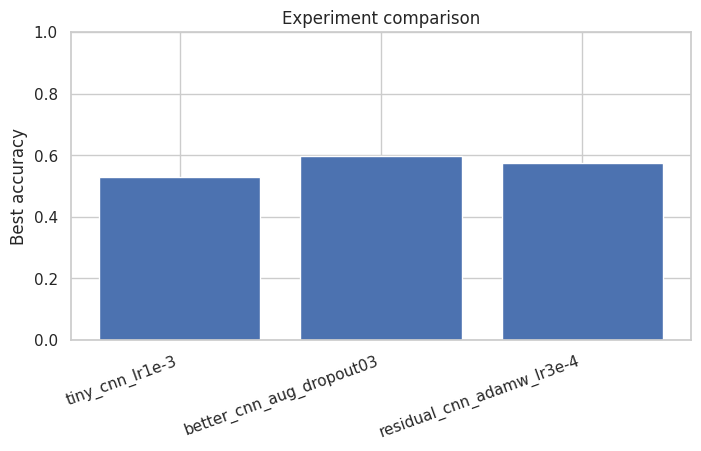

In [32]:
if results:
    names = [r["config"]["run_name"] for r in results]
    scores = [r["best_acc"] for r in results]
    plt.figure(figsize=(8, 4))
    plt.bar(names, scores)
    plt.xticks(rotation=20, ha="right")
    plt.ylabel("Best accuracy")
    plt.title("Experiment comparison")
    plt.ylim(0, 1)
    plt.show()

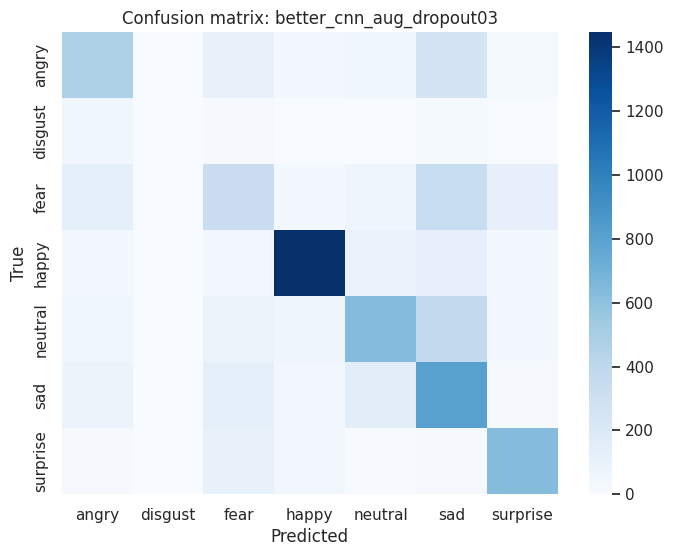

In [33]:
if results:
    best = max(results, key=lambda r: r["best_acc"])
    cm = confusion_matrix(best["labels"], best["preds"])
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion matrix: {best['config']['run_name']}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

In [35]:
import pandas as pd

summary = pd.DataFrame([
    {
        "run": r["config"]["run_name"],
        "model": r["config"]["model"],
        "lr": r["config"]["learning_rate"],
        "dropout": r["config"]["dropout"],
        "augment": r["config"]["augment"],
        "epochs": r["config"]["epochs"],
        "best_acc": r["best_acc"],
    }
    for r in results
])

summary

,run,model,lr,dropout,augment,epochs,best_acc
0,tiny_cnn_lr1e-3,tiny_cnn,0.0010,0.25,False,5,0.528559
1,better_cnn_aug_dropout03,better_cnn,0.0010,0.30,True,10,0.598913
2,residual_cnn_adamw_lr3e-4,residual_cnn,0.0003,0.40,True,10,0.575648


### final notes

After training, copy scores and Wandb links into `README.md`.

Before running, my guess:

- TinyCNN should be the weakest but is useful as a baseline.
- BetterCNN should improve because it has more feature capacity and regularization.
- ResidualCNN may improve further, but if it does not, that is still useful: it means extra architecture complexity did not beat the simpler tuned CNN under my training budget.

Main thing: show what I tried and whether it helped.